# Lecture 2  -  Solutions

Run cells from top to bottom. Requires NumPy, Matplotlib, librosa, and IPython. Audio downloads the original recording and requires internet access. All convolutions use the full output. a filter of length M adds M−1 samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1  -  Sine-wave function

In Lecture 1, you generated time samples and sine-wave samples directly in your notebook. Turn that code into a reusable function duration, samplerate, amplitude, and frequency are now arguments rather than fixed values in the code. This lets you generate different signals by calling the same function.

Return two 1D NumPy arrays the time samples and the sine samples. Both arrays must contain the same number of samples. Exclude the endpoint of the time interval.

### Solution

Lecture 1 generated one signal directly. Here, a reusable function takes the signal settings as arguments, so the same code can generate different signals.

`samplerate * duration` gives the sample count. Exclude the endpoint so the spacing is exactly `1 / samplerate`. both returned arrays have equal length.

In [2]:
def get_sine_data(frequency=1, amplitude=1, samplerate=100, duration=2):
    time = np.arange(round(samplerate * duration)) / samplerate
    sine = amplitude * np.sin(2 * np.pi * frequency * time)
    return time, sine

time, x = get_sine_data()
print("Time samples", len(time), "Sine samples", len(x))

Time samples 200 Sine samples 200


## Exercise 2  -  Phase shift

Extend the function from Exercise 1 with a phase-shift argument, given in radians. Plot a sine wave with and without a phase shift to check it.

### Solution

Add the phase in radians inside the sine. The following extends the same function.

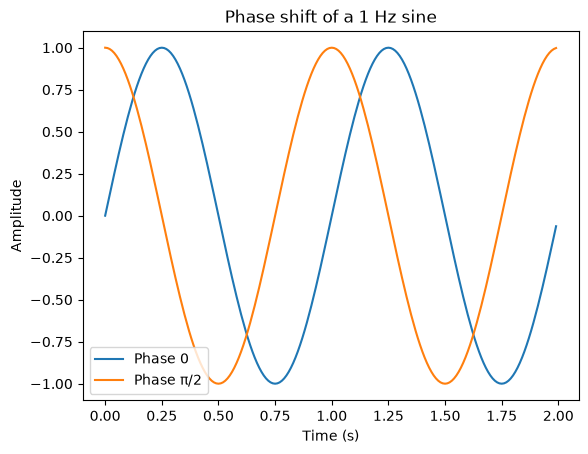

In [3]:
def get_sine_data(frequency=1, amplitude=1, phase_shift=0, samplerate=100, duration=2):
    time = np.arange(round(samplerate * duration)) / samplerate
    sine = amplitude * np.sin(2 * np.pi * frequency * time + phase_shift)
    return time, sine

time, x = get_sine_data()
_, x_shifted = get_sine_data(phase_shift=np.pi / 2)
plt.plot(time, x, label="Phase 0")
plt.plot(time, x_shifted, label="Phase π/2")
plt.title("Phase shift of a 1 Hz sine")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## Exercise 3  -  Convolution and the impulse response

In Lecture 1, you used the properties of an LTI system to determine the output from its impulse response.

Use

$$
x[n] = 2\delta[n] - \delta[n-2] + 3\delta[n-5]
$$

and the impulse response

$$
h[n] = \delta[n] + 0.5\delta[n-1].
$$

Create `x` and `h` as NumPy arrays and use `np.convolve` to calculate the output $y[n]$.

Plot `x`, `h` and `y` using `plt.stem()`.

Compare the result with the method used in Lecture 1. What is convolution doing for us here?

### Solution

Use 10 samples for `x` and `h`, as in Lecture 1. Convolution automatically adds the scaled and shifted impulse responses $y[n]=2h[n]-h[n-2]+3h[n-5]$.

Same output as the LTI method True
y [ 2.   1.  -1.  -0.5  0.   3.   1.5  0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0. ]


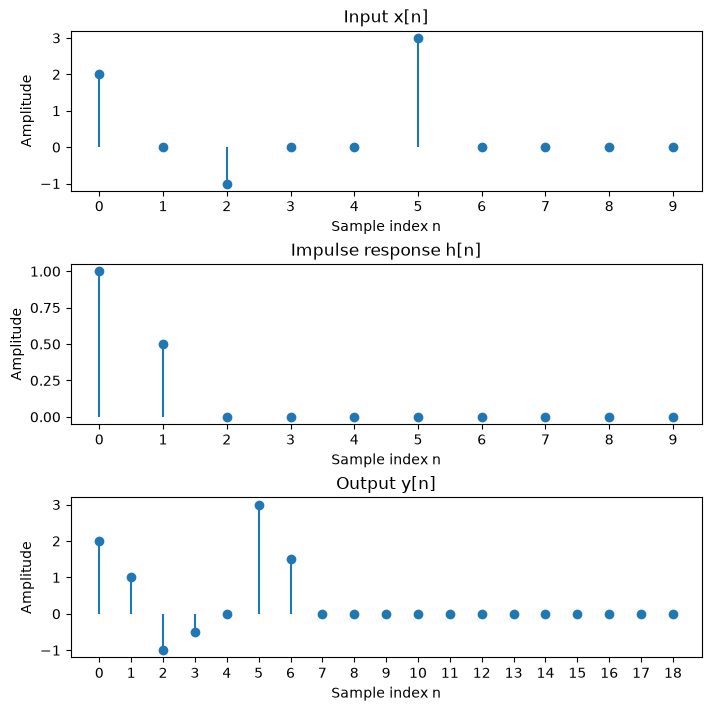

In [4]:
x = np.zeros(10)
x[0], x[2], x[5] = 2, -1, 3
# Alternative x = np.array([2, 0, -1, 0, 0, 3, 0, 0, 0, 0])

h = np.zeros(10)
h[0], h[1] = 1, 0.5
# Alternative h = np.array([1, 0.5, 0, 0, 0, 0, 0, 0, 0, 0])

y = np.convolve(x, h)

# Quickly recreating lecture 1 method, for comparison. Zero-padded to the full convolution length.
y_lti = (2 * np.pad(h, (0, 9)) - np.pad(h, (2, 7)) + 3 * np.pad(h, (5, 4)))

print("Same output as the LTI method", np.allclose(y, y_lti))
print("y", y)

# The following is a fancy plotting methods using subplots such that it becomes one figure, it is nice, but not required.
fig, axes = plt.subplots(3, 1, figsize=(7, 7), constrained_layout=True)

axes[0].stem(np.arange(len(x)), x, basefmt=" ")
axes[0].set(title="Input x[n]", xlabel="Sample index n", ylabel="Amplitude")
axes[0].set_xticks(np.arange(len(x)))

axes[1].stem(np.arange(len(h)), h, basefmt=" ")
axes[1].set(title="Impulse response h[n]", xlabel="Sample index n", ylabel="Amplitude")
axes[1].set_xticks(np.arange(len(h)))

axes[2].stem(np.arange(len(y)), y, basefmt=" ")
axes[2].set(title="Output y[n]", xlabel="Sample index n", ylabel="Amplitude")
axes[2].set_xticks(np.arange(len(y)))
plt.show()

The nonzero output samples are `[2, 1, -1, -0.5, 0, 3, 1.5]`. They match Lecture 1. all remaining samples are zero. Full convolution of two 10-sample arrays returns 19 samples, including trailing zeros. Basically, convolution does the scaling, shifting, and addition for us.

## Exercise 4  -  Moving average

Generate a 5 Hz sine wave with `samplerate=100` Hz, duration 2 seconds, and amplitude 1. Apply a 10-sample moving average using `np.convolve`. The filter weights must sum to 1. Plot the original and filtered signals and briefly describe the effect.

### Solution

The impulse response has ten weights of 0.1 each output sample averages ten consecutive input samples. The weights sum to 1, so a constant input is preserved (other than at the edges).

Full convolution gives 200 + 10 − 1 = 209 samples, reusing the original time array would not work, as it is shorter in length. Therefore it was opted to just plot against sample index to see the discrete convolution directly. The averaging smooths this sine, and also delays it a little bit.

Impulse response [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


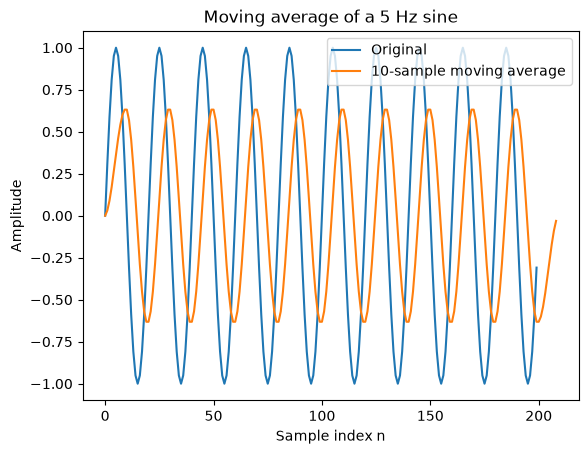

In [5]:
_, x = get_sine_data(frequency=5, samplerate=100, duration=2)
impulse_response = np.ones(10) / 10  # The impulse response is a 10-sample moving average filter
print(f"Impulse response {impulse_response}")

y = np.convolve(x, impulse_response)

plt.plot(x, label="Original")
plt.plot(y, label="10-sample moving average")
plt.title("Moving average of a 5 Hz sine")
plt.xlabel("Sample index n")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## Exercise 5  -  Low and high frequencies

Sum a low-frequency and a high-frequency sine wave. Before filtering, predict which frequency a moving average will affect most. Apply the moving average using `np.convolve`, plot the original and filtered signals, and compare your prediction with the result.

For example 5 Hz and 20 Hz, `samplerate=500` Hz, duration 0.5 seconds, and a 50-sample moving average.

### Solution

Prediction with this 50-sample window at 500 Hz, the 20 Hz component is attenuated more than the 5 Hz component, meaning its amplitude is reduced more. Averaging spans two full 20 Hz cycles, so that component cancels away from the edges. The sum is filtered directly.

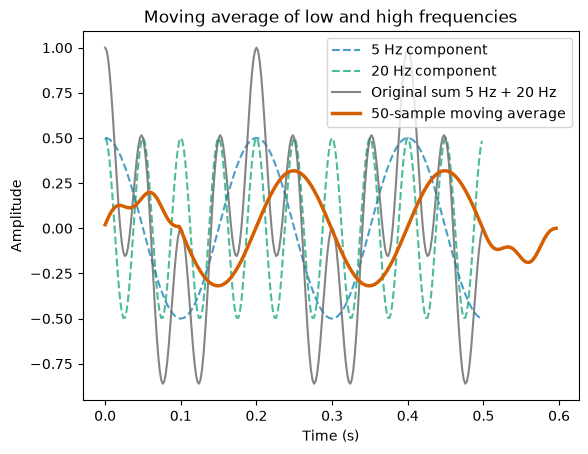

In [6]:
samplerate = 500
time, x_low = get_sine_data(frequency=5, amplitude=0.5, phase_shift=np.pi/2, samplerate=samplerate, duration=0.5)
_, x_high = get_sine_data(frequency=20, amplitude=0.5, phase_shift=np.pi/2, samplerate=samplerate, duration=0.5)
x = x_low + x_high

impulse_response = np.ones(50) / 50
y = np.convolve(x, impulse_response)


# Plotting with some different styles and colors, to make it more clear which line is which.
plt.plot(time, x_low, color="#0072B2", linestyle="--", alpha=0.7, label="5 Hz component")
plt.plot(time, x_high, color="#009E73", linestyle="--", alpha=0.7, label="20 Hz component")
plt.plot(time, x, color="#666666", alpha=0.8, label="Original sum 5 Hz + 20 Hz")
plt.plot(np.arange(len(y)) / samplerate, y, color="#D55E00", linewidth=2.5, label="50-sample moving average")
plt.title("Moving average of low and high frequencies")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## Exercise 6  -  Filter audio

Download the recording from its original source using the example below. Keep its original sample rate.

- Listen to the original sound.
- Apply 10-sample, 100-sample and 1000-sample moving averages using `np.convolve`. For each filter, use equal weights that sum to one and keep the full convolution output.
- Listen to all three filtered recordings at the original sample rate. Use `normalize=False` for all audio players so automatic rescaling does not hide differences in loudness.
- Plot the same short section of the original and all three filtered signals on a common time axis.
- Describe how the window length affects what you hear and see. Compare smoothing, amplitude and delay.
- Report the original and all three filtered signal lengths. Explain how each window length changes the output length.

```python
import urllib.request
import librosa
from IPython.display import Audio, display

file_name = "2776.mp3"
url = f"https://bigsoundbank.com/UPLOAD/mp3/{file_name}"
urllib.request.urlretrieve(url, file_name)
sound_data, samplerate = librosa.load(file_name, sr=None)
display(Audio(sound_data, rate=samplerate, normalize=False))
```

Source https://bigsoundbank.com/detail-2776-cockatiel-parakeet-8.html

### Solution

Use equal weights `np.ones(window_size) / window_size` for each window. Keep the original sample rate and disable automatic normalisation in every audio player. Store the three outputs in `filtered_signals`, indexed by their window length, so you can reuse each one later.

Original recording
Number of samples 275328


10-sample moving average
Number of samples 275337
Added samples 9


100-sample moving average
Number of samples 275427
Added samples 99


1000-sample moving average
Number of samples 276327
Added samples 999


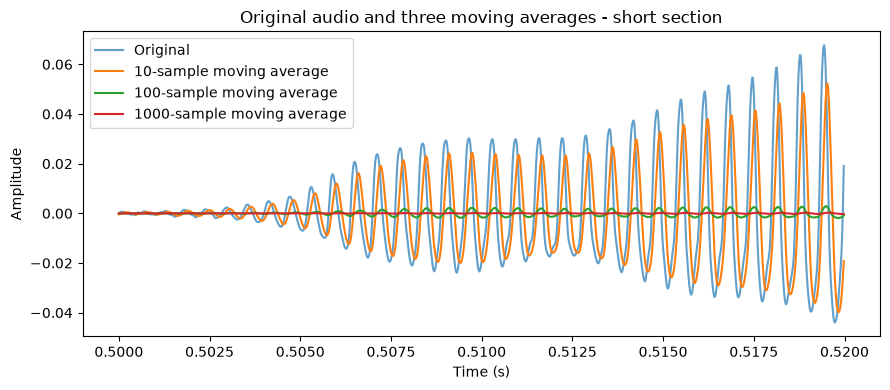

In [7]:
import urllib.request
import librosa
from IPython.display import Audio, display

file_name = "2776.mp3"
url = f"https://bigsoundbank.com/UPLOAD/mp3/{file_name}"
urllib.request.urlretrieve(url, file_name)
sound_data, samplerate = librosa.load(file_name, sr=None)

print("Original recording")
print("Number of samples", len(sound_data))
display(Audio(sound_data, rate=samplerate, normalize=False))

# Show the same 20 ms section of each signal, starting at 0.5 seconds.
start = int(0.5 * samplerate)
stop = start + int(0.02 * samplerate)
section_time = np.arange(start, stop) / samplerate
plt.figure(figsize=(9, 4))
plt.plot(section_time, sound_data[start:stop], label="Original", alpha=0.7)

filtered_signals = {}
for window_size in [10, 100, 1000]:
    impulse_response = np.ones(window_size) / window_size
    filtered_signals[window_size] = np.convolve(sound_data, impulse_response, mode="full")
    filtered_sound = filtered_signals[window_size]
    print(f"{window_size}-sample moving average")
    print("Number of samples", len(filtered_sound))
    print("Added samples", len(filtered_sound) - len(sound_data))
    display(Audio(filtered_sound, rate=samplerate, normalize=False))
    plt.plot(section_time, filtered_sound[start:stop], label=f"{window_size}-sample moving average")

plt.title("Original audio and three moving averages - short section")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

Longer averaging windows generally suppress more rapid variation. For this recording, the 10-sample result stays closer to the original, while the 100-sample and 1000-sample results are much more attenuated. Compare the players without automatic normalisation to hear the changes in loudness and brightness. A moving average has frequency-dependent cancellation, so increasing the window does not reduce every individual frequency monotonically.

Full convolution adds $M-1$ samples for a window of length $M$. The 10-sample, 100-sample and 1000-sample filters therefore add 9, 99 and 999 samples respectively. For the supplied recording's 275,328 samples, the output lengths are 275,337, 275,427 and 276,327.

The corresponding delays are $(M-1)/2$, giving 4.5, 49.5 and 499.5 samples. At 48,000 Hz these are approximately 0.094 ms, 1.031 ms and 10.406 ms. The plot uses the same time interval without compensating for these delays, so you see both attenuation and timing changes.

Use `filtered_signals[100]` when you need the 100-sample moving-average output for Lecture 3.

Source https://bigsoundbank.com/detail-2776-cockatiel-parakeet-8.html

## Exercise 7  -  Manual convolution

Implement convolution manually, without using `np.convolve` inside your implementation. Recreate the 5 Hz sine wave and 10-sample moving-average filter as in Exercise 4 (`samplerate=100` Hz, duration 2 seconds).

Compare your result with `np.convolve` plot both outputs, check whether their values match (allowing for floating-point round-off), and compare their lengths.

### Solution

Recreate the sine wave and filter from Exercise 4 below. Flip the filter, zero-pad the input, multiply overlapping samples, and sum. Both implementations below produce the full 209-sample output.

In [8]:
samplerate = 100
time, x = get_sine_data(frequency=5, samplerate=samplerate, duration=2)
impulse_response = np.ones(10) / 10

### Method A  -  Sliding dot product

In [9]:
def my_convolution(a, b):
    output_length = len(a) + len(b) - 1
    if len(a) < len(b):
        a, b = b, a
    b = np.flip(b)
    padding_length = len(b) - 1
    padded_a = np.pad(a, (padding_length, padding_length))
    return np.array([np.sum(padded_a[i:i+len(b)] * b) for i in range(output_length)])

y_manual = my_convolution(x, impulse_response)

### Method B  -  Double loop

Alternatively, sum the products whose input indices are in range.

Same values (sliding dot product): True
Same values (double loop): True
Lengths (NumPy, sliding dot product, double loop): 209 209 209


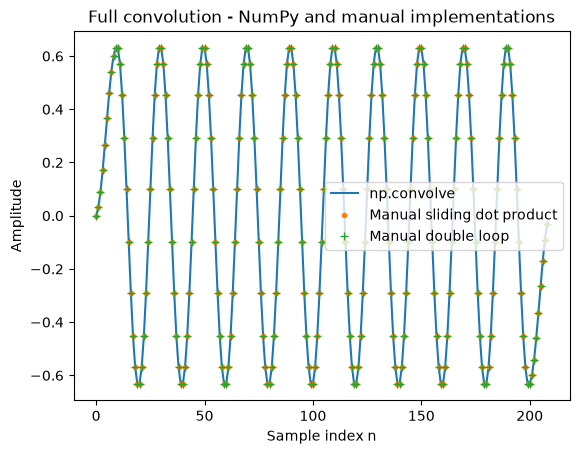

In [10]:
def my_convolution_double_for_loop(a, b):
    result = np.zeros(len(a) + len(b) - 1)
    for i in range(len(result)):
        for j in range(len(b)):
            if 0 <= i - j < len(a):
                result[i] += a[i - j] * b[j]
    return result

y_double_loop = my_convolution_double_for_loop(x, impulse_response)
y_reference = np.convolve(x, impulse_response)
print("Same values (sliding dot product):", np.allclose(y_manual, y_reference))
print("Same values (double loop):", np.allclose(y_double_loop, y_reference))
print("Lengths (NumPy, sliding dot product, double loop):", len(y_reference), len(y_manual), len(y_double_loop))

plt.plot(y_reference, label="np.convolve")
plt.plot(y_manual, '.', label="Manual sliding dot product")
plt.plot(y_double_loop, '+', label="Manual double loop")
plt.title("Full convolution - NumPy and manual implementations")
plt.xlabel("Sample index n")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

Both comparisons are true values match within floating-point round-off, and all outputs have 209 samples.